In [1]:
"""
SIF regional maps
@L. Leverne/F. Maignan
"""

#import
import pandas as pd
from netCDF4 import Dataset
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm as cm
from matplotlib import ticker 
import numpy as np
import glob
import math
import xarray as xr
import netCDF4
import seaborn as sns
from mpl_toolkits.basemap import Basemap
from statsmodels.formula.api import ols
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter

In [2]:
#https://stackoverflow.com/questions/18195758/set-matplotlib-colorbar-size-to-match-graph
def add_colorbar(im, aspect=20, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

In [3]:
def rmse(observation, prediction):
    RMSE =math.sqrt(np.nanmean((np.array(observation)-np.array(prediction))**2))
    RMSE= round(RMSE,3)
    return RMSE

In [4]:
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [5]:
def bias(prediction,observation):
    bias = (prediction - observation).mean()
    return bias

In [6]:
def plot_map(sif,vmin_SIF,vmax_SIF,palette):
    precision=40
    nbins=round((vmax_SIF-vmin_SIF)*precision)
    count=nbins
    min_val, max_val = 0.0,1.0
    n = 100
    orig_cmap = plt.get_cmap(palette)
    colors = orig_cmap(np.linspace(min_val, max_val, n))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("mycmap", colors, count)
    
    fig, ax = plt.subplots(figsize=(7,7))
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    cs = m.pcolormesh(xi,yi,np.squeeze(sif),cmap=cmap,vmin=vmin_SIF,vmax=vmax_SIF)
    # Add Grid Lines
    m.drawparallels(np.arange(-90., 91., 10.), labels=[1,0,0,0], fontsize=12)
    m.drawmeridians(np.arange(-180., 181., 30.), labels=[0,0,0,1], fontsize=12)
    # Add Coastlines, States, and Country Boundaries
    m.drawcoastlines()

    # Add Colorbar
    tick_locator = ticker.MaxNLocator(nbins=math.ceil(nbins/2))
    cbar = m.colorbar(cs, location='bottom', pad="15%",ticks=tick_locator)
    cbar.ax.yaxis.set_ticks([])
    cbar.ax.yaxis.set_ticklabels([])
    cbar.update_ticks()
    cbar.ax.set_title('SIF annual mean ($\mathrm{W.m^{-2}.\mu m^{-1}.sr^{-1}}$)',fontsize=fontsize_label)    
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    cbar.ax.tick_params(labelsize=12)

In [7]:
def plot_map_diff(sif,vmin_SIF,vmax_SIF,palette):
    precision=40
    nbins=round((vmax_SIF-vmin_SIF)*precision)
    count=nbins
    min_val, max_val = 0.0,1.0
    n = 100
    orig_cmap = plt.get_cmap(palette)
    colors = orig_cmap(np.linspace(min_val, max_val, n))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("mycmap", colors, count)
    
    # Step 1: Define discrete colors (example uses 5 bins: 2 below, grey, 2 above)
    colors = [
        (0, 0, 0.5),       # Very dark blue (lowest)
        (0, 0, 1),         # Dark blue
        (0.4, 0.4, 1),     # Light blue
        (0.7, 0.7, 0.7),   # Grey (middle)
        (1, 0.6, 0.6),     # Light red
        (1, 0.2, 0.2),     # Medium red
        (0.6, 0, 0)        # Dark red (highest)
    ]
    nbins=len(colors)
    # Step 2: Create the colormap
    cmap_diff = ListedColormap(colors, name='red-grey-blue')

    # Step 3: Define bin edges to match your range
    # For 5 colors => 6 boundaries:
    bounds = np.linspace(vmin_SIF, vmax_SIF, len(colors) + 1)
    norm = BoundaryNorm(bounds, cmap_diff.N)

    fig, ax = plt.subplots(figsize=(7,7))
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    cs = m.pcolormesh(xi,yi,np.squeeze(sif),cmap=cmap_diff,norm=norm)
    # Add Grid Lines
    m.drawparallels(np.arange(-90., 91., 10.), labels=[1,0,0,0], fontsize=12)
    m.drawmeridians(np.arange(-180., 181., 30.), labels=[0,0,0,1], fontsize=12)
    # Add Coastlines, States, and Country Boundaries
    m.drawcoastlines()

    # Add Colorbar
    tick_locator = bounds
    cbar = m.colorbar(cs, location='bottom', pad="15%",ticks=tick_locator)
    cbar.ax.yaxis.set_ticks([])
    cbar.ax.yaxis.set_ticklabels([])
    cbar.update_ticks()
    cbar.ax.set_title('SIF annual mean ($\mathrm{W.m^{-2}.\mu m^{-1}.sr^{-1}}$)',fontsize=fontsize_label)    
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    cbar.ax.tick_params(labelsize=12)

In [8]:
fontsize_title=16
fontsize_label=14
fontsize_legend=12

seuil=0.5
obs = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_obs_200122.nc')
obs = obs.rename_dims({'record':'time_counter'})
obs = obs.rename({'record':'time_counter'})
bacour = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_prior_200122.nc')
raczka = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_raczka_200122.nc')
optsif = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_optsif_200122.nc')
optgpp = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_optgpp_200122.nc')
bacouropt = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_bacouropt_200122.nc')

obs = obs.sel(time_counter=slice("2018-05-01", "2020-12-31"))
bacour = bacour.sel(time_counter=slice("2018-05-01", "2020-12-31"))
raczka = raczka.sel(time_counter=slice("2018-05-01", "2020-12-31"))
optsif = optsif.sel(time_counter=slice("2018-05-01", "2020-12-31"))
optgpp = optgpp.sel(time_counter=slice("2018-05-01", "2020-12-31"))
bacouropt = bacouropt.sel(time_counter=slice("2018-05-01", "2020-12-31"))

#Masking to keep common grid cells
mask = np.isnan(obs.SIF_Corr_743) | np.isnan(raczka.SIF_2fluxRTM_FM) 
obs['SIF_Corr_743'] = xr.where(mask,np.nan,obs.SIF_Corr_743)
bacour['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,bacour.SIF_2fluxRTM_FM)
raczka['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,raczka.SIF_2fluxRTM_FM)
optsif['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,optsif.SIF_2fluxRTM_FM)
optgpp['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,optgpp.SIF_2fluxRTM_FM)

#Setting negative SIF observations to zero
mask_negative = obs['SIF_Corr_743'] < 0
obs['SIF_Corr_743'] = obs['SIF_Corr_743'].where(~mask_negative, 0)

/tmp/ipykernel_21810/3775000400.py:8: UserWarning: rename 'record' to 'time_counter' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  obs = obs.rename({'record':'time_counter'})


In [9]:
if True:
    #Plot
    obs  = obs.mean("time_counter")
    bacour  = bacour.mean("time_counter")
    raczka  = raczka.mean("time_counter")
    optgpp  = optgpp.mean("time_counter")
    optsif  = optsif.mean("time_counter")
    bacouropt  = bacouropt.mean("time_counter")

    simu=raczka.SIF_2fluxRTM_FM
    obs=obs.SIF_Corr_743
    diff=simu-obs

    lons = simu.lon
    lats = simu.lat

    # Get some parameters for the Stereographic Projection
    lon_0 = lons.mean()
    lat_0 = lats.mean()
                
    m = Basemap(projection='npstere',boundinglat=45,lon_0=0,resolution='l')

    lon, lat = np.meshgrid(lons, lats)
    xi, yi = m(lon, lat)

/tmp/ipykernel_21810/3785852226.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(sif),cmap=cmap,vmin=vmin_SIF,vmax=vmax_SIF)


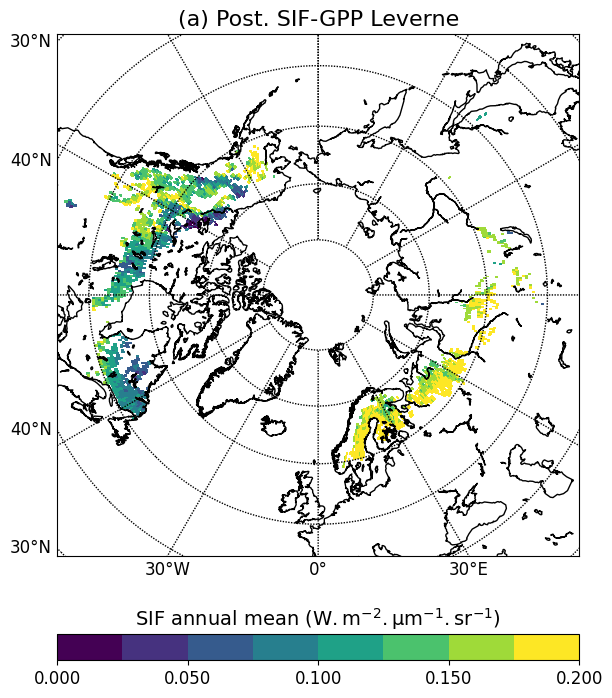

In [10]:
if True:
    vmin_SIF=0
    vmax_SIF=0.2
    palette='viridis'    

    #Simulation
    plot_map(simu,vmin_SIF,vmax_SIF,palette)
    plt.title('(a) Post. SIF-GPP Leverne',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4a.png')

/tmp/ipykernel_21810/3785852226.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(sif),cmap=cmap,vmin=vmin_SIF,vmax=vmax_SIF)


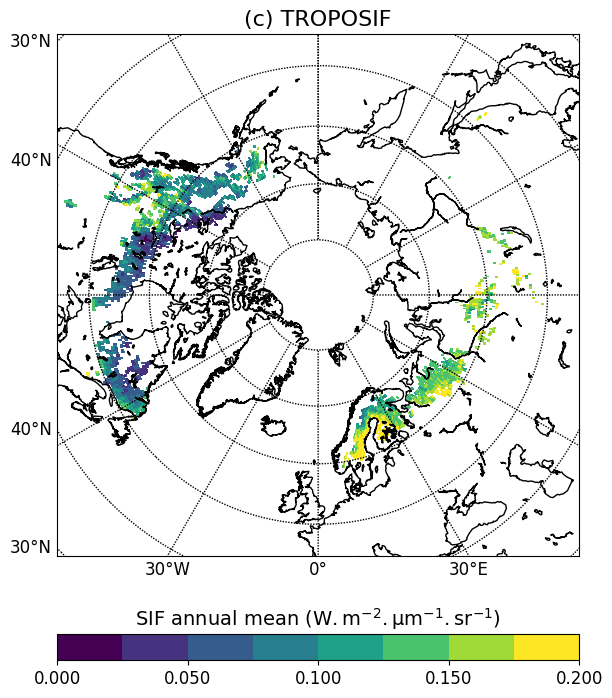

In [11]:
if True:
    vmin_SIF=0
    vmax_SIF=0.2
    palette='viridis'  
    
    #Obs
    plot_map(obs,vmin_SIF,vmax_SIF,palette)
    plt.title('(c) TROPOSIF',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4c.png')

/tmp/ipykernel_21810/1474189493.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(sif),cmap=cmap_diff,norm=norm)


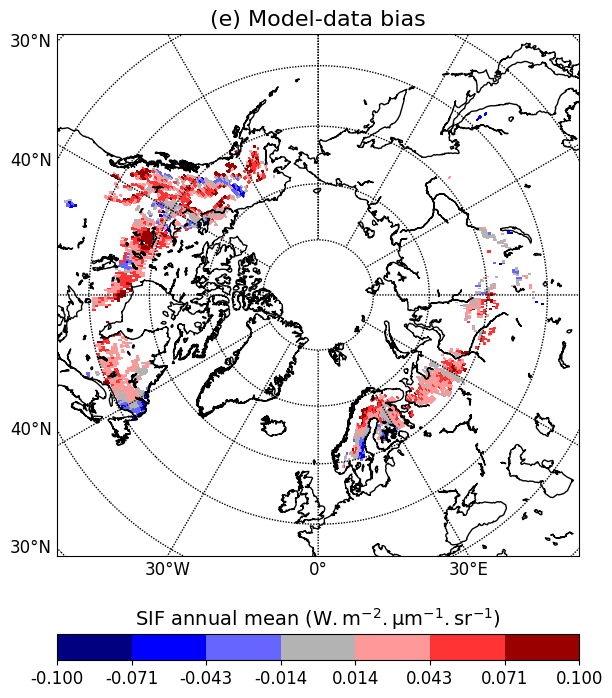

In [12]:
if True:
    #Difference
    vmin_SIF=-0.1
    vmax_SIF=0.1    
    palette='seismic'

    plot_map_diff(diff,vmin_SIF,vmax_SIF,palette)
    plt.title('(e) Model-data bias',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4e.png')